# Visual Module — Evaluation

Compares the two visual backends the module exposes:

| Backend | What it is |
|---|---|
| **Work-placement model** | `dima806/ai_vs_real_image_detection` + the `run_01_stage2A` int8 weight delta, fine-tuned on `combined_dataset`. The model the report's Stage-2 results use. |
| **Community Forensics** | `OwensLab/commfor-model-384`, official weights from Park & Owens (arXiv:2411.04125), used out of the box with no fine-tuning. `commfor-model-224` is the cheaper variant of the same architecture. |

Three test sets, in increasing order of how much they tell you:

1. **Sample images** (`data/sample_images/`) — 12 images, ground truth in the filename prefix. Fast smoke test.
2. **`combined_dataset` test split** — 3,462 held-out images, the split the report's figures use. **In-distribution for the work-placement model**, which was fine-tuned on the train split of the same julienlucas + ntire + deepfakejudge mixture.
3. **Community Forensics eval set** — external to both models: 21 generators paired with reals from RAISE/COCO/FFHQ/LAION. This is the only set here that neither backend was fitted to, so it is the one that compares them fairly. It is 206 GB upstream, so the notebook scores a capped, index-selected subset — see Test 3.

Everything reusable lives in `visual_classifier.py` and `evaluation.py`; this notebook only orchestrates and displays.

In [1]:
import os
import sys

import numpy as np
import pandas as pd
from PIL import Image

# Notebooks run from src/visual_module/, so bootstrap the project root first —
# module code imports through the `src.` prefix.
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from src.visual_module import (
    COMMFOR_MODEL_224,
    COMMFOR_MODEL_384,
    CommunityForensicsClassifier,
    VisualClassifier,
    get_delta_base_model,
)
from src.visual_module import evaluation as ev

print("Project root:", PROJECT_ROOT)

Project root: /Users/davidscerri/Library/Mobile Documents/com~apple~CloudDocs/Studies/Masters/Thesis/Proof-of-Concept/Seeing-Through-Deepfakes


## Configuration

Edit this cell and run the notebook top to bottom.

In [2]:
RUN_NAME = "run_07_visual_backend_comparison"

# Canonical fused decision threshold (David, 2026-07-19). Reporting each stream
# at the same threshold keeps these numbers comparable to what fusion sees.
THRESHOLD = 0.55

SAMPLE_DIR = os.path.join(PROJECT_ROOT, "data", "sample_images")
TEST_SPLIT_DIR = os.path.join(PROJECT_ROOT, "data", "visual", "combined_dataset", "test")
OUTPUT_DIR = os.path.join(PROJECT_ROOT, "src", "visual_module", "outputs")

VISUAL_DELTA_PATH = os.path.join(
    PROJECT_ROOT, "src", "visual_module", "fine_tuned_model_delta",
    "run_01_stage2A_ft_combined_weight_delta.pt",
)

# Set to an int to score only the first N images of the test split while
# iterating; None runs the full 3,462.
TEST_LIMIT = None

# The 224 checkpoint is the same architecture at lower resolution. Off by
# default — enable to check whether CF's misses are resolution-related.
INCLUDE_COMMFOR_224 = False

# Community Forensics eval set: 413 parquet shards, 206 GB in full, so the
# shards to score are chosen from the committed index rather than downloaded
# wholesale. Aim for this many images of EACH class per generator...
COMMFOR_MIN_PER_CLASS = 24

# ...but never pull a shard bigger than this. Shard size tracks the generator's
# output resolution and ranges from 4.7 MB to 2.9 GB; the largest hold 25
# images per ~550 MB row group, so an uncapped run spends hours fetching a
# handful of images. Generators excluded by the cap are reported, not hidden.
#
# 512 MB is the sweet spot measured against the index: all 21 generators in
# 4.1 GB. Tightening to 256 MB drops LCM_lora_sdxl; 128 MB drops four
# generators (1.3 GB). Loosening to 1 GB buys no extra coverage and costs 6.4.
COMMFOR_MAX_SHARD_MB = 512

# Cap on images taken per shard, bounding decode time on high-resolution
# generators. None = the whole shard.
COMMFOR_MAX_IMAGES_PER_SHARD = 64

BATCH_SIZE = 16

## Load the classifiers

The base model is derived from the delta rather than hardcoded — `load_weight_delta`
raises on a mismatch, since a delta applied to the wrong base yields a model that is
neither the base nor the fine-tuned one.

In [3]:
base_model = get_delta_base_model(VISUAL_DELTA_PATH)
print("Delta records base model:", base_model)

work_placement = VisualClassifier(
    model_name_or_path=base_model,
    delta_path=VISUAL_DELTA_PATH,
)
print("Work-placement model ready on", work_placement.device)

Delta records base model: dima806/ai_vs_real_image_detection


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

Applying weight delta from '/Users/davidscerri/Library/Mobile Documents/com~apple~CloudDocs/Studies/Masters/Thesis/Proof-of-Concept/Seeing-Through-Deepfakes/src/visual_module/fine_tuned_model_delta/run_01_stage2A_ft_combined_weight_delta.pt'...
Delta applied successfully.
Work-placement model ready on mps


In [4]:
commfor = CommunityForensicsClassifier(repo_id=COMMFOR_MODEL_384)
print(f"Community Forensics ready on {commfor.device} (input {commfor.input_size}px)")

classifiers = {
    "Work placement (fine-tuned ViT)": work_placement,
    "Community Forensics 384": commfor,
}

if INCLUDE_COMMFOR_224:
    classifiers["Community Forensics 224"] = CommunityForensicsClassifier(
        repo_id=COMMFOR_MODEL_224
    )

list(classifiers)

Community Forensics ready on mps (input 384px)


['Work placement (fine-tuned ViT)', 'Community Forensics 384']

## Test 1 — sample images

Ground truth comes from the filename prefix (`{real|ai|deepfake}...`); `ai` and
`deepfake` are both the positive (AI-generated) class.

In [5]:
sample_paths = sorted(
    os.path.join(SAMPLE_DIR, f)
    for f in os.listdir(SAMPLE_DIR)
    if not f.startswith(".")
)
sample_images = [Image.open(p) for p in sample_paths]
sample_labels = np.array([
    0 if os.path.basename(p).startswith("real") else 1 for p in sample_paths
])

sample_probs = {
    name: np.asarray(ev.ai_probabilities(clf, sample_images))
    for name, clf in classifiers.items()
}

samples_table = pd.DataFrame(
    {"image": [os.path.basename(p) for p in sample_paths],
     "truth": np.where(sample_labels == 1, "AI-Generated", "Real"),
     **{name: probs.round(4) for name, probs in sample_probs.items()}}
).set_index("image")

samples_table

,truth,Work placement (fine-tuned ViT),Community Forensics 384
image,,,
ai+metadata-place-face.png,AI-Generated,0.8264,0.0046
ai-metadata-place-face.png,AI-Generated,0.8264,0.0046
deepfake+metadata+place-face.png,AI-Generated,0.0625,0.2027
deepfake+metadata-place+face.png,AI-Generated,0.0668,0.7108
deepfake-metadata+place-face.png,AI-Generated,0.0625,0.2027
deepfake-metadata-place+face.png,AI-Generated,0.0668,0.7108
real+metadata+place-face.jpg,Real,0.1460,0.0071
real+metadata-place+face.jpeg,Real,0.2917,0.0003
real+metadata-place-face.jpeg,Real,0.1147,0.0000


In [6]:
sample_metrics = {
    name: ev.metrics_at(probs, sample_labels, THRESHOLD)
    for name, probs in sample_probs.items()
}
pd.DataFrame(sample_metrics).T[["n", "auc", "accuracy", "precision", "recall", "f1"]]

,n,auc,accuracy,precision,recall,f1
Work placement (fine-tuned ViT),12,0.333333,0.666667,1.0,0.333333,0.5
Community Forensics 384,12,0.888889,0.666667,1.0,0.333333,0.5


## Test 2 — `combined_dataset` test split

Streams the arrow shards directly rather than `load_from_disk()`, which stalls
materialising the corpus from iCloud. Expect several minutes per classifier.

In [7]:
split_probs, split_labels = {}, None

for name, clf in classifiers.items():
    print(f"Scoring {name}...")
    probs, labels = ev.score_split(
        clf, TEST_SPLIT_DIR, batch_size=BATCH_SIZE, limit=TEST_LIMIT
    )
    split_probs[name] = probs
    split_labels = labels   # identical ordering across classifiers
    print(f"  done: {len(probs)} images")

Scoring Work placement (fine-tuned ViT)...
  scored 320...
  scored 640...
  scored 960...
  scored 1280...
  scored 1600...
  scored 1920...
  scored 2240...
  scored 2560...
  scored 2880...
  scored 3200...
  done: 3462 images
Scoring Community Forensics 384...
  scored 320...
  scored 640...
  scored 960...
  scored 1280...
  scored 1600...
  scored 1920...
  scored 2240...
  scored 2560...
  scored 2880...
  scored 3200...
  done: 3462 images


In [8]:
split_metrics = {
    name: ev.metrics_at(probs, split_labels, THRESHOLD)
    for name, probs in split_probs.items()
}
pd.DataFrame(split_metrics).T[["n", "auc", "accuracy", "precision", "recall", "f1"]]

,n,auc,accuracy,precision,recall,f1
Work placement (fine-tuned ViT),3462,0.921318,0.841421,0.854229,0.823121,0.838387
Community Forensics 384,3462,0.821762,0.739746,0.859497,0.572832,0.687478


### Score distribution

Community Forensics is strongly bimodal and high-precision / low-recall: it is
confident when it fires, but a substantial share of AI images score near zero.
This is the behaviour that matters for fusion — it complements a high-recall
stream rather than replacing one.

In [9]:
pd.DataFrame({
    name: {
        "real median": float(np.median(probs[split_labels == 0])),
        "AI median": float(np.median(probs[split_labels == 1])),
        "AI scoring < 0.05 (missed)": float((probs[split_labels == 1] < 0.05).mean()),
        "real scoring > 0.95 (false alarm)": float((probs[split_labels == 0] > 0.95).mean()),
    }
    for name, probs in split_probs.items()
}).T.round(4)

,real median,AI median,AI scoring < 0.05 (missed),real scoring > 0.95 (false alarm)
Work placement (fine-tuned ViT),0.1306,0.8500,0.0006,0.0000
Community Forensics 384,0.0003,0.9426,0.3445,0.0497


## Test 3 — Community Forensics eval set (external to both models)

The decisive comparison. Test 2 is in-distribution for the work-placement
model — it was fine-tuned on the train split of the same corpus — so a strong
score there measures fit to `combined_dataset`, not detection ability in
general. Neither model has seen anything here.

### Choosing shards

A shard is **not** one generator with its paired reals: a generator spans many
shards, and an individual shard is frequently all-real or all-AI (`model_name`
on a real row records the generator it is paired *against*). Sampling shards at
even intervals therefore lands generators with only one class present, whose AP
is undefined.

So selection is driven by a committed index of every shard's generator, class
counts and byte size — built once by `build_commfor_eval_index.py` over
metadata columns only, never downloading image bytes. The plan below picks the
cheapest shards that give each generator both classes.

Reference point from the dataset card, for `commfor-model-384` over the full
413 shards: **mAP 0.987, mAcc 0.893**. A capped subset will not land exactly
there, but should be close if the wiring is right.

In [10]:
index = ev.commfor_eval_index()

eval_shards, plan = ev.select_commfor_eval_shards(
    index,
    min_per_class=COMMFOR_MIN_PER_CLASS,
    max_shard_bytes=COMMFOR_MAX_SHARD_MB * 1024**2,
)

planned_bytes = sum(index[s]["bytes"] for s in eval_shards)
print(f"{len(eval_shards)} shards, {len(plan['generators'])} generators, "
      f"{planned_bytes / 1024**3:.1f} GB (cached after the first run)")

if plan["skipped"]:
    print(f"\nExcluded by the {COMMFOR_MAX_SHARD_MB} MB cap:")
    for entry in plan["skipped"]:
        print(f"  {entry['generator']:32s} smallest shard "
              f"{entry['smallest_bytes'] / 1024**2:.0f} MB")

pd.DataFrame(plan["generators"]).T[["n_real", "n_ai", "bytes"]].assign(
    MB=lambda df: (df["bytes"] / 1024**2).round(1)
).drop(columns="bytes")

44 shards, 21 generators, 4.1 GB (cached after the first run)


,n_real,n_ai,MB
DFGAN,126,125,19.6
Dalle2,126,126,197.3
Dalle3,26,100,159.9
DeciDiffusionV2,7,245,252.4
FLUX-dev,126,125,43.6
FLUX-schnell,125,126,44.6
Firefly_Image2,34,92,40.8
Firefly_Image3,126,126,57.8
GALIP,2,375,77.3
Hourglass,124,126,17.1


Scoring streams row batches straight from each shard, so memory stays flat, and
logs every shard before fetching it — a multi-gigabyte download is otherwise
indistinguishable from a hang.

In [11]:
cf_eval_probs, cf_eval_labels, cf_eval_generators = {}, None, None

for name, clf in classifiers.items():
    print(f"Scoring {name} on the Community Forensics eval set...")
    probs, labels, generators = ev.score_commfor_eval(
        clf,
        eval_shards,
        batch_size=BATCH_SIZE,
        max_images_per_shard=COMMFOR_MAX_IMAGES_PER_SHARD,
        index=index,
    )
    cf_eval_probs[name] = probs
    cf_eval_labels, cf_eval_generators = labels, generators
    print(f"  done: {len(probs)} images over {len(set(generators))} generators\n")

Scoring Work placement (fine-tuned ViT) on the Community Forensics eval set...
  [1/44] shard 5 DFGAN (14 MB)... 32 images in 1s
  [2/44] shard 12 MidjourneyV6_1 (5 MB)... 32 images in 1s
  [3/44] shard 19 stable_cascade (196 MB)... 33 images in 2s
  [4/44] shard 21 stable_cascade (173 MB)...

/opt/homebrew/lib/python3.14/site-packages/PIL/TiffImagePlugin.py:949: UserWarning: Truncated File Read
  warnings.warn(str(msg))


 32 images in 2s
  [5/44] shard 23 stable_cascade (188 MB)... 33 images in 2s
  [6/44] shard 30 MidjourneyV5_2 (175 MB)... 32 images in 2s
  [7/44] shard 46 GALIP (10 MB)... 32 images in 1s
  [8/44] shard 60 LCM_lora_sdxl (449 MB)... 46 images in 6s
  [9/44] shard 62 LCM_lora_sdxl (202 MB)... 32 images in 2s
  [10/44] shard 74 MidjourneyV6_1 (175 MB)... 32 images in 2s
  [11/44] shard 82 Hourglass (5 MB)... 32 images in 1s
  [12/44] shard 91 kvikontent_midjourney_v6 (80 MB)... 33 images in 1s
  [13/44] shard 92 kvikontent_midjourney_v6 (246 MB)... 41 images in 2s
  [14/44] shard 120 GALIP (32 MB)... 33 images in 3s
  [15/44] shard 124 GALIP (35 MB)... 33 images in 2s
  [16/44] shard 135 FLUX-dev (7 MB)... 32 images in 1s
  [17/44] shard 142 FLUX-schnell (38 MB)... 32 images in 1s
  [18/44] shard 148 IdeogramV2 (181 MB)... 32 images in 2s
  [19/44] shard 154 Hourglass (13 MB)... 32 images in 1s
  [20/44] shard 188 FLUX-schnell (6 MB)... 32 images in 1s
  [21/44] shard 191 LCM_lora_ssd1b

/opt/homebrew/lib/python3.14/site-packages/PIL/Image.py:1137: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


 64 images in 3s
  [24/44] shard 216 kvikontent_midjourney_v6 (79 MB)... 33 images in 2s
  [25/44] shard 217 kvikontent_midjourney_v6 (58 MB)... 32 images in 1s
  [26/44] shard 218 kvikontent_midjourney_v6 (149 MB)... 36 images in 1s
  [27/44] shard 226 Dalle3 (160 MB)... 58 images in 4s
  [28/44] shard 232 IdeogramV2 (6 MB)...

...

 32 images in 1s
  [29/44] shard 238 Imagen3 (41 MB)...

[transformers] The channel dimension is ambiguous. Got image shape torch.Size([3, 1, 1]). Assuming channels are the first dimension. Use the [input_data_format](https://huggingface.co/docs/transformers/main/internal/image_processing_utils#transformers.image_transforms.rescale.input_data_format) parameter to assign the channel dimension.


 64 images in 2s
  [30/44] shard 244 kandinsky_2_2 (103 MB)... 32 images in 1s
  [31/44] shard 246 kandinsky_2_2 (127 MB)... 33 images in 1s
  [32/44] shard 253 Dalle2 (192 MB)... 32 images in 2s
  [33/44] shard 301 FLUX-dev (37 MB)... 32 images in 1s
  [34/44] shard 311 DeciDiffusionV2 (53 MB)... 32 images in 1s
  [35/44] shard 316 DeciDiffusionV2 (200 MB)... 39 images in 3s
  [36/44] shard 332 Firefly_Image3 (52 MB)... 32 images in 2s
  [37/44] shard 340 Firefly_Image3 (6 MB)... 32 images in 1s
  [38/44] shard 344 Dalle2 (6 MB)...

[transformers] The channel dimension is ambiguous. Got image shape torch.Size([3, 1, 1]). Assuming channels are the first dimension. Use the [input_data_format](https://huggingface.co/docs/transformers/main/internal/image_processing_utils#transformers.image_transforms.rescale.input_data_format) parameter to assign the channel dimension.


 32 images in 1s
  [39/44] shard 352 DFGAN (6 MB)... 32 images in 1s
  [40/44] shard 357 LCM_lora_sdv15 (26 MB)... 64 images in 2s
  [41/44] shard 360 LCM_lora_sdv15 (41 MB)... 32 images in 1s
  [42/44] shard 371 MidjourneyV5_2 (6 MB)... 32 images in 1s
  [43/44] shard 386 IdeogramV1 (5 MB)... 32 images in 1s
  [44/44] shard 407 IdeogramV1 (191 MB)... 32 images in 2s
  done: 1577 images over 21 generators

Scoring Community Forensics 384 on the Community Forensics eval set...
  [1/44] shard 5 DFGAN (14 MB)... 32 images in 1s
  [2/44] shard 12 MidjourneyV6_1 (5 MB)... 32 images in 1s
  [3/44] shard 19 stable_cascade (196 MB)... 33 images in 2s
  [4/44] shard 21 stable_cascade (173 MB)... 32 images in 2s
  [5/44] shard 23 stable_cascade (188 MB)... 33 images in 2s
  [6/44] shard 30 MidjourneyV5_2 (175 MB)... 32 images in 2s
  [7/44] shard 46 GALIP (10 MB)... 32 images in 1s
  [8/44] shard 60 LCM_lora_sdxl (449 MB)... 46 images in 6s
  [9/44] shard 62 LCM_lora_sdxl (202 MB)... 32 images i

In [12]:
cf_eval_metrics = {
    name: ev.per_generator_metrics(
        probs, cf_eval_labels, cf_eval_generators, THRESHOLD,
        min_per_class=COMMFOR_MIN_PER_CLASS,
    )
    for name, probs in cf_eval_probs.items()
}

pd.DataFrame({
    name: {
        "n": m["n"],
        "generators": m["n_generators"],
        "generators balanced": m["n_generators_balanced"],
        "mAP (balanced)": m["mAP_balanced"],
        "mAcc (balanced)": m["mAcc_balanced"],
        "mAP (all)": m["mAP"],
        "mAcc (all)": m["mAcc"],
        "pooled AUC": m["pooled"]["auc"],
        "pooled accuracy": m["pooled"]["accuracy"],
        "pooled recall": m["pooled"]["recall"],
    }
    for name, m in cf_eval_metrics.items()
}).T.round(4)

,n,generators,generators balanced,mAP (balanced),mAcc (balanced),mAP (all),mAcc (all),pooled AUC,pooled accuracy,pooled recall
Work placement (fine-tuned ViT),1577.0,21.0,10.0,0.6816,0.6160,0.7672,0.6761,0.7613,0.6703,0.6268
Community Forensics 384,1577.0,21.0,10.0,0.9950,0.8947,0.9951,0.9311,0.9939,0.9398,0.9173


**Quote the balanced columns.** Some generators keep their real images only in
shards above the size cap, so their sample is nearly all-AI — and AP over a
group that is 250 AI to 1 real sits near 1.0 for any ranking whatsoever. The
balanced figures average only over generators holding at least
`COMMFOR_MIN_PER_CLASS` of *both* classes; the `(all)` columns are the
unfiltered equivalents, kept for comparison against the dataset card.

Pooled metrics are computed over every image at once and are unaffected by this.

### Per-generator breakdown

Where each model's coverage holds and where it falls away. AP is the paper's
per-generator metric; the `mAP` above is the mean of this column.

`NaN` means that generator arrived with no paired real images in the sampled
shards, so AP is undefined — raise `COMMFOR_EVAL_SHARDS` to pull in more of
each generator's pairing. Accuracy is still defined there (it just measures
recall on that generator's fakes).

Watch AP against accuracy: a high AP with low accuracy means the model *ranks*
that generator's images correctly but its probabilities sit on the wrong side
of the threshold — a calibration failure, not a detection failure.

In [13]:
first = next(iter(cf_eval_metrics.values()))["per_generator"]

per_gen = pd.DataFrame({
    ("", "n_real"): {g: r["n_real"] for g, r in first.items()},
    ("", "n_ai"): {g: r["n_ai"] for g, r in first.items()},
    ("", "balanced"): {g: r["balanced"] for g, r in first.items()},
    **{
        (name, metric): {g: r[metric] for g, r in m["per_generator"].items()}
        for name, m in cf_eval_metrics.items()
        for metric in ("ap", "accuracy")
    },
})
per_gen.columns = pd.MultiIndex.from_tuples(per_gen.columns)
per_gen.sort_values(("", "balanced"), ascending=False).round(4)

Work placement (fine-tuned ViT)  \
                         n_real n_ai balanced                              ap   
DFGAN                        64   34     True                          0.4117   
Firefly_Image3               32   32     True                          0.7320   
MidjourneyV6_1               32   32     True                          0.6731   
MidjourneyV5_2               32   34     True                          0.7777   
IdeogramV2                   32   32     True                          0.7139   
Dalle2                       33   44     True                          0.7330   
Hourglass                    32   32     True                          0.5350   
IdeogramV1                   32   32     True                          0.6584   
FLUX-schnell                 49   45     True                          0.8300   
Dalle3                       26   32     True                          0.7507   
GALIP                         2   96    False                          0.9949   
Firefly_Image2               32   19    False                          0.4287   
FLUX-dev                     21   32    False                          0.9651   
Imagen3                      32    0    False                             NaN   
LCM_lora_sdv15                0   64    False                             NaN   
LCM_lora_sdxl                14   64    False                          0.9129   
LCM_lora_ssd1b                0   64    False                             NaN   
DeciDiffusionV2               7   64    False                          0.9793   
kandinsky_2_2                 0   78    False                             NaN   
kvikontent_midjourney_v6     15  164    False                          0.9487   
stable_cascade                2   94    False                          0.9968   

                                  Community Forensics 384           
                         accuracy                      ap accuracy  
DFGAN                      0.5918                  1.0000   1.0000  
Firefly_Image3             0.6094                  0.9885   0.7500  
MidjourneyV6_1             0.5938                  0.9870   0.7344  
MidjourneyV5_2             0.6515                  0.9940   0.9242  
IdeogramV2                 0.6406                  0.9916   0.7812  
Dalle2                     0.5974                  0.9990   0.8961  
Hourglass                  0.5000                  1.0000   0.9531  
IdeogramV1                 0.5781                  0.9925   0.9531  
FLUX-schnell               0.7766                  0.9995   0.9894  
Dalle3                     0.6207                  0.9982   0.9655  
GALIP                      0.4592                  1.0000   0.9694  
Firefly_Image2             0.4902                  0.9696   0.8431  
FLUX-dev                   0.8302                  1.0000   0.9434  
Imagen3                    0.8438                     NaN   1.0000  
LCM_lora_sdv15             0.9062                     NaN   0.9844  
LCM_lora_sdxl              0.6667                  0.9974   0.9359  
LCM_lora_ssd1b             0.8594                     NaN   1.0000  
DeciDiffusionV2            0.7042                  1.0000   0.9859  
kandinsky_2_2              0.8077                     NaN   0.9487  
kvikontent_midjourney_v6   0.6480                  1.0000   0.9944  
stable_cascade             0.8229                  1.0000   1.0000

## Figures

  Figure saved to /Users/davidscerri/Library/Mobile Documents/com~apple~CloudDocs/Studies/Masters/Thesis/Proof-of-Concept/Seeing-Through-Deepfakes/src/visual_module/outputs/run_07_visual_backend_comparison_confusion_matrices.png


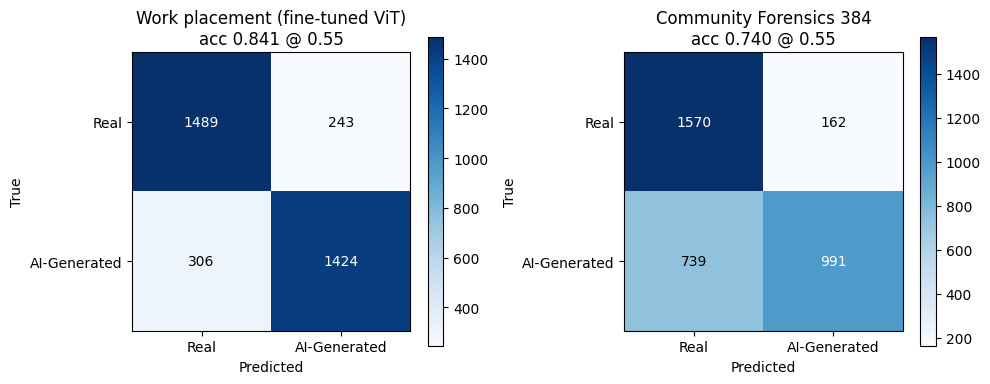

In [14]:
%matplotlib inline

ev.plot_confusion_matrices(
    split_metrics,
    output_path=os.path.join(OUTPUT_DIR, f"{RUN_NAME}_confusion_matrices.png"),
);

ROC on both large test sets. The gap between the two panels is the point of the
whole notebook: in-distribution versus external.

  Figure saved to /Users/davidscerri/Library/Mobile Documents/com~apple~CloudDocs/Studies/Masters/Thesis/Proof-of-Concept/Seeing-Through-Deepfakes/src/visual_module/outputs/run_07_visual_backend_comparison_roc.png


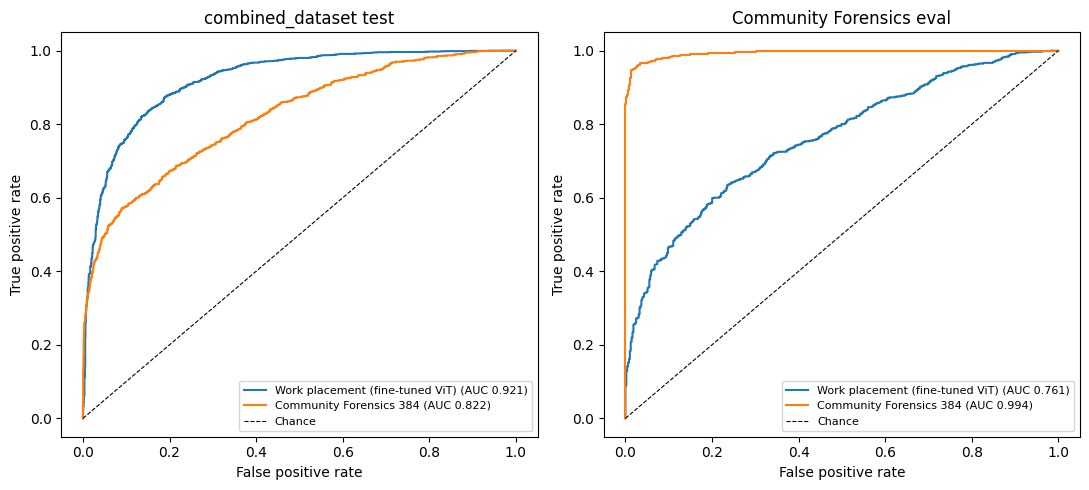

In [15]:
ev.plot_roc(
    {
        "combined_dataset test": {name: (probs, split_labels)
                                  for name, probs in split_probs.items()},
        "Community Forensics eval": {name: (probs, cf_eval_labels)
                                     for name, probs in cf_eval_probs.items()},
    },
    output_path=os.path.join(OUTPUT_DIR, f"{RUN_NAME}_roc.png"),
);

## Save results

In [16]:
ev.save_results(
    {
        "threshold": THRESHOLD,
        "delta_base_model": base_model,
        "delta_path": os.path.relpath(VISUAL_DELTA_PATH, PROJECT_ROOT),
        "samples12": {
            "metrics": sample_metrics,
            "probs": {
                name: dict(zip(samples_table.index, probs.round(4).tolist()))
                for name, probs in sample_probs.items()
            },
        },
        "combined_test": split_metrics,
        "community_forensics_eval": {
            "shards": eval_shards,
            "total_shards": ev.COMMFOR_EVAL_TOTAL_SHARDS,
            "min_per_class": COMMFOR_MIN_PER_CLASS,
            "max_shard_mb": COMMFOR_MAX_SHARD_MB,
            "max_images_per_shard": COMMFOR_MAX_IMAGES_PER_SHARD,
            "selection": plan,
            "metrics": cf_eval_metrics,
        },
    },
    os.path.join(OUTPUT_DIR, f"{RUN_NAME}_eval_results.json"),
)

  Metrics saved to /Users/davidscerri/Library/Mobile Documents/com~apple~CloudDocs/Studies/Masters/Thesis/Proof-of-Concept/Seeing-Through-Deepfakes/src/visual_module/outputs/run_07_visual_backend_comparison_eval_results.json
